# Global fires from MODIS:

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy import linalg
from datetime import datetime, timedelta
import pickle

# Import the csv datasets:
# -----------------------
dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Global-fires/global-MODIS/MCD64A1_burned_area_full_dataset_2002-2023.csv.gz' \
                      ,delim_whitespace=False,sep=',',na_values='NaN',comment='#' \
                      ,skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
header = dataset.iloc[:, :].columns
# deivide by 100 to convert from hectares to km^2:
global_forest_fire_area_raw_input=np.asarray(data[:,6]).flatten()/100
global_savanna_fire_area_raw_input=np.asarray(data[:,7]).flatten()/100
global_all_fire_area_raw_input=(np.sum(np.asarray(data[:,6:11]),1)/100)
global_shrub_grass_fire_area_raw_input=np.asarray(data[:,8]).flatten()/100
global_crop_fire_area_raw_input=np.asarray(data[:,9]).flatten()/100
global_fire_years_raw_input=np.asarray(data[:,0]).flatten()

print("Done loading libnraries and data.")

/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_24329/1575367407.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/Global-fires/global-MODIS/MCD64A1_burned_area_full_dataset_2002-2023.csv.gz' \


Done loading libnraries and data.


In [2]:
# calculate yearly totals:

year_beg=np.min(global_fire_years_raw_input)
year_end=np.max(global_fire_years_raw_input)
global_fire_years=np.asarray(np.arange(year_beg,year_end+1,1))
Nyears=len(global_fire_years)
global_fire_years.shape=(Nyears,1)
global_forest_fire_area=np.zeros((Nyears,1))
global_savanna_fire_area=np.zeros((Nyears,1))
global_shrub_grass_fire_area=np.zeros((Nyears,1))
global_crop_fire_area=np.zeros((Nyears,1))
global_all_fire_area=np.zeros((Nyears,1))
iyear=0
for year in global_fire_years:
    global_forest_fire_area[iyear]=\
       np.sum(global_forest_fire_area_raw_input[global_fire_years_raw_input==year])
    global_savanna_fire_area[iyear]=\
       np.sum(global_savanna_fire_area_raw_input[global_fire_years_raw_input==year])
    global_shrub_grass_fire_area[iyear]=\
       np.sum(global_shrub_grass_fire_area_raw_input[global_fire_years_raw_input==year])
    global_crop_fire_area[iyear]=\
       np.sum(global_crop_fire_area_raw_input[global_fire_years_raw_input==year])
    global_all_fire_area[iyear]=\
       np.sum(global_all_fire_area_raw_input[global_fire_years_raw_input==year])
    iyear=iyear+1

sum=global_forest_fire_area+global_savanna_fire_area\
     +global_shrub_grass_fire_area+global_crop_fire_area

print("done.")

done.


In [3]:
# load older giglio global data
#y=np.load("Output/to-pickle/global_fire_area_years.npy")
#a=np.load("Output/to-pickle/global_fire_area.npy")

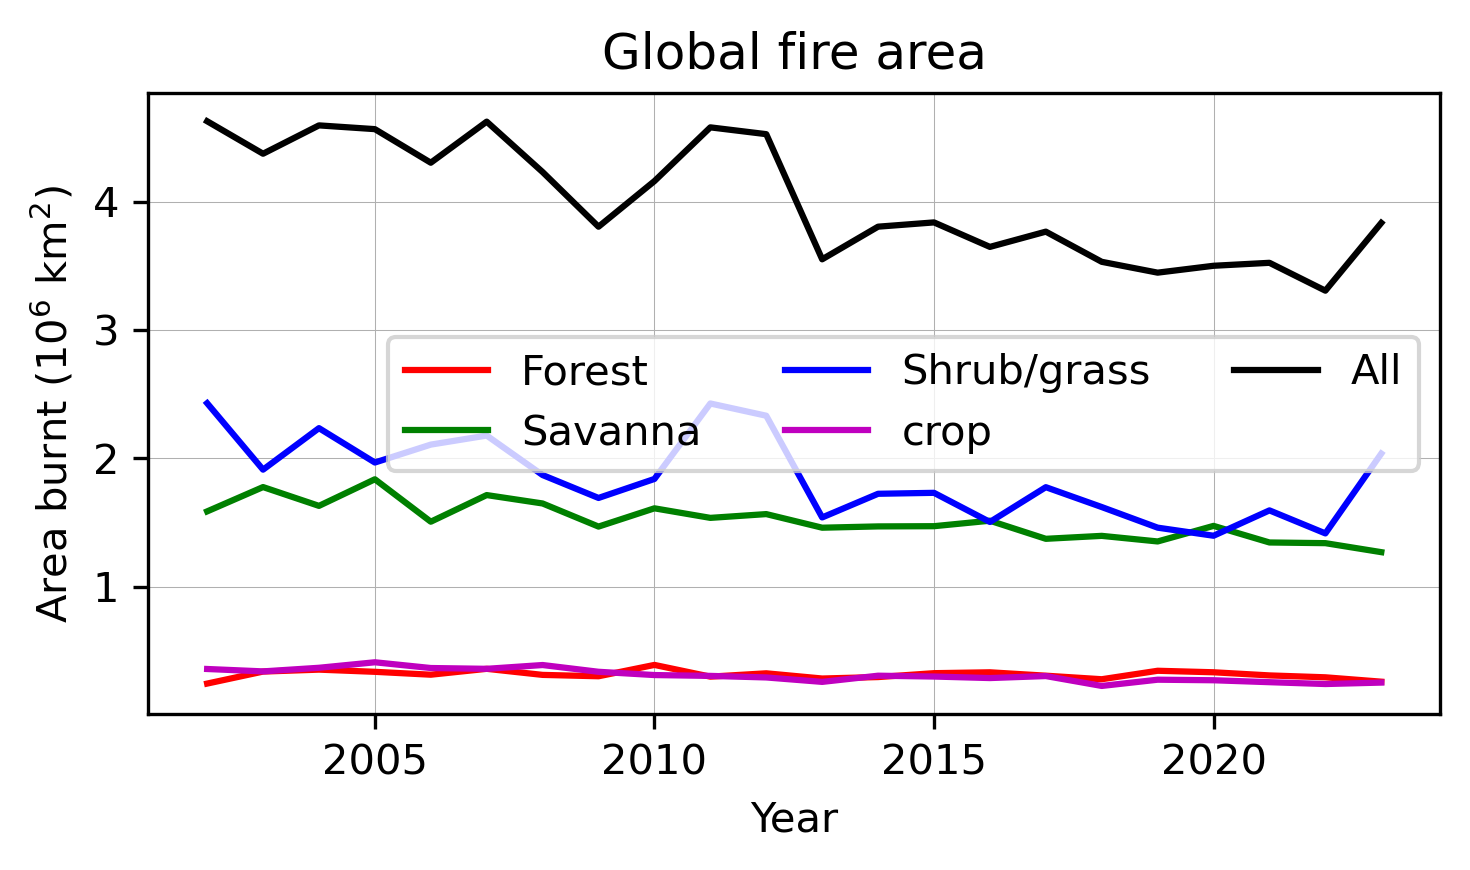

In [4]:
# plot:
plt.figure(figsize=(5,3),dpi=300)
plt.plot(global_fire_years,global_forest_fire_area/1.e6,'r',label="Forest")
plt.plot(global_fire_years,global_savanna_fire_area/1.e6,'g',label="Savanna")
plt.plot(global_fire_years,global_shrub_grass_fire_area/1.e6,'b',label="Shrub/grass")
plt.plot(global_fire_years,global_crop_fire_area/1.e6,'m',label="crop")
plt.plot(global_fire_years,global_all_fire_area/1.e6,'k',label="All")
#plt.plot(global_fire_years,sum/1.e6,'--k',label="All")
#plt.plot(y,a/1.e6,'k',label="old All")
plt.xlabel("Year")
plt.ylabel("Area burnt ($10^6$ km$^2$)")
plt.title("Global fire area")
plt.legend(ncol=3)
plt.grid(lw=0.25)


plt.tight_layout()

In [5]:
np.save("Output/to-pickle/global_fire_years",global_fire_years)
np.save("Output/to-pickle/global_forest_fire_area",global_forest_fire_area)
np.save("Output/to-pickle/global_savanna_fire_area",global_savanna_fire_area)
np.save("Output/to-pickle/global_shrub_grass_fire_area",global_shrub_grass_fire_area)
np.save("Output/to-pickle/global_crop_fire_area",global_crop_fire_area)
np.save("Output/to-pickle/global_all_fire_area",global_all_fire_area)
print("done.")

done.
